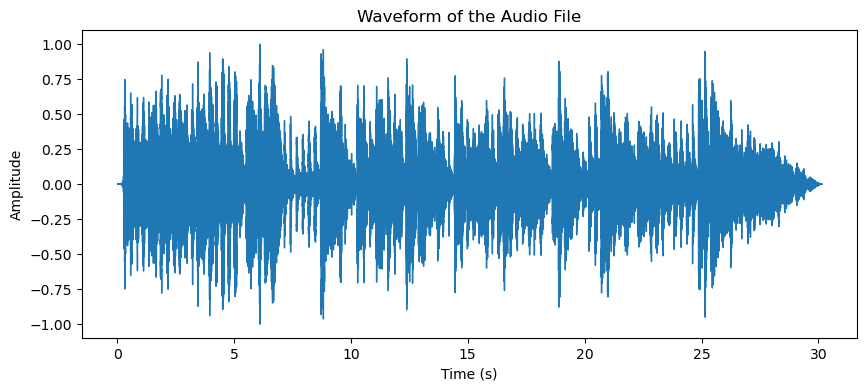

In [ ]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

# Step 1: Load audio file, convert to mono and normalise amplitude.
def load_audio(file_path, target_sr=44100):

    # Load the audio file and make it mono
    y, sr = librosa.load(file_path, sr=target_sr, mono=True)

    # Normalize the signal to the range [-1, 1]
    y = y / np.max(np.abs(y))

    return y, sr

# Load an audio file
audio_path = "Albums-Mambo_Kings-03.wav"
y, sr = load_audio(audio_path)

# Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of the Audio File")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

# Play the audio
Audio(y, rate=sr)


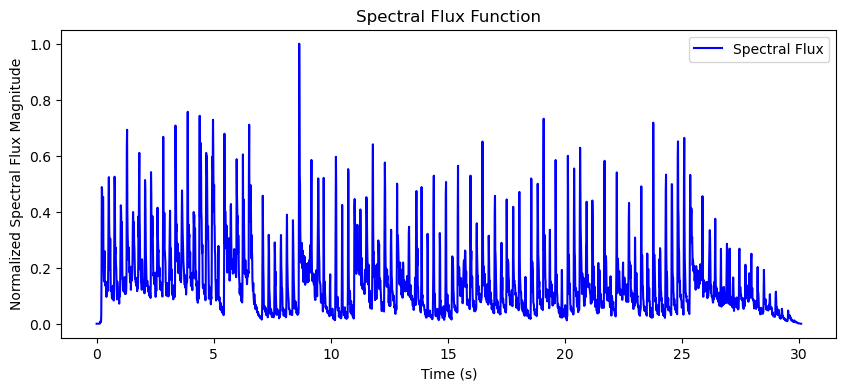

In [ ]:
# Step 2: Compute Spectral Flux

def compute_spectral_flux(y, sr, frame_size=2048, hop_size=512):

    # Compute Short-Time Fourier Transform (STFT)
    num_frames = 1 + (len(y) - frame_size) // hop_size
    window = np.hamming(frame_size)  # Hamming window to smooth edges

    # Initialize STFT matrix
    stft_magnitude = np.zeros((frame_size // 2 + 1, num_frames))

    # Compute magnitude spectrum for each frame
    for n in range(num_frames):
        start = n * hop_size
        end = start + frame_size
        frame = y[start:end] * window
        spectrum = np.fft.rfft(frame)  # Compute FFT and keep only positive frequencies
        stft_magnitude[:, n] = np.abs(spectrum)

    # Compute Spectral Flux
    spectral_flux = np.zeros(num_frames - 1)
    for n in range(1, num_frames):
        diff = stft_magnitude[:, n] - stft_magnitude[:, n - 1]
        spectral_flux[n - 1] = np.sum(np.maximum(diff, 0))  # Only positive changes are counted

    # Normalize Spectral Flux
    spectral_flux = spectral_flux / np.max(spectral_flux)

    # Compute time stamps for frames
    times = np.arange(len(spectral_flux)) * (hop_size / sr)

    return spectral_flux, times

# Compute Spectral Flux
spectral_flux, times = compute_spectral_flux(y, sr)

# Plot Spectral Flux
plt.figure(figsize=(10, 4))
plt.plot(times, spectral_flux, label="Spectral Flux", color='b')
plt.title("Spectral Flux Function")
plt.xlabel("Time (s)")
plt.ylabel("Normalized Spectral Flux Magnitude")
plt.legend()
plt.show()


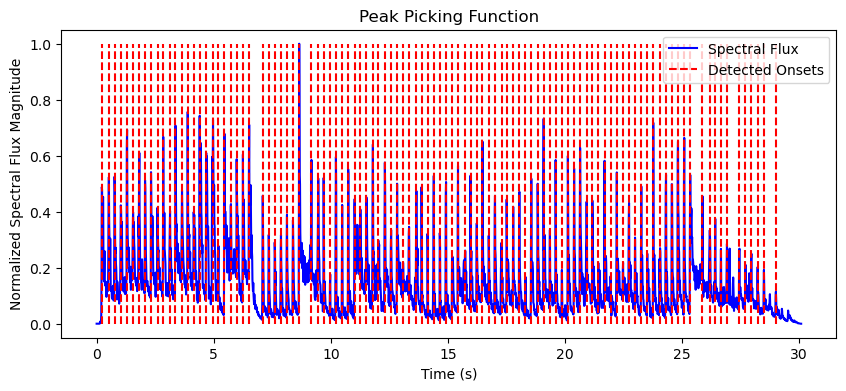

In [ ]:
# Step 3: Pick Peaking Function

def peak_picking(spectral_flux, times, hop_size=512, sr=44100, window_size=1, delta=0.1, alpha=0.1):

    # Moving average threshold for each frame
    moving_avg = np.convolve(spectral_flux, np.ones(window_size) / window_size, mode='same')
    peaks = []

    # Loop through spectral_flux, skipping edges
    for i in range(window_size, len(spectral_flux) - window_size):
        # 1. Local Maximum Check
        if spectral_flux[i] == max(spectral_flux[i - window_size : i + window_size]):

            # 2. Local Threshold (larger neighborhood)
            local_window = spectral_flux[max(0, i - 3 *window_size) : i + 3*window_size]
            threshold = np.mean(local_window) + delta

            # 3. Smoothing Condition
            smoothed_prev = alpha * spectral_flux[i - 1] + (1 - alpha) * threshold
            if spectral_flux[i] >= threshold and spectral_flux[i] > smoothed_prev:
                peaks.append(i)

    # Convert peak indices to time values
    onset_times = np.array(peaks) * (hop_size / sr)
    return peaks, onset_times
    # Plot results
plt.figure(figsize=(10, 4))
plt.plot(times, spectral_flux, label="Spectral Flux", color='b')
plt.vlines(onset_times, min(spectral_flux), max(spectral_flux), color='r', linestyle='--', label="Detected Onsets")
plt.title("Peak Picking Function")
plt.xlabel("Time (s)")
plt.ylabel("Normalized Spectral Flux Magnitude")
plt.legend()
plt.show()

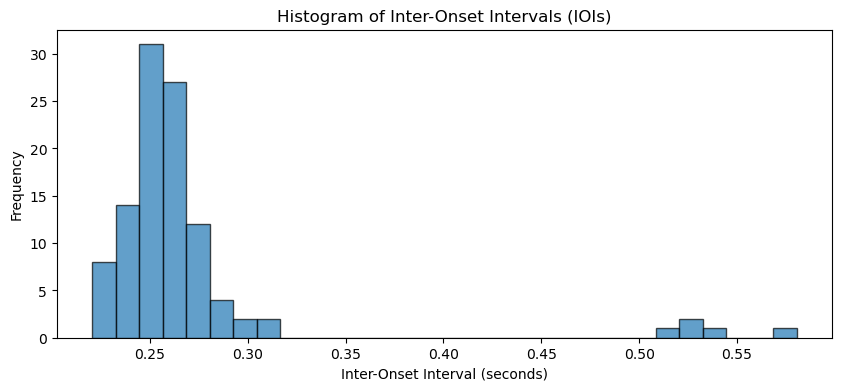

Clustered Rhythmic Levels:
Rhythmic Level 1: Mean IOI = 0.302 sec, Count = 20
Rhythmic Level 2: Mean IOI = 0.244 sec, Count = 51
Rhythmic Level 3: Mean IOI = 0.267 sec, Count = 27
Rhythmic Level 4: Mean IOI = 0.580 sec, Count = 2
Rhythmic Level 5: Mean IOI = 0.522 sec, Count = 3
Rhythmic Level 6: Mean IOI = 0.221 sec, Count = 2


In [ ]:
# Step 4: Create IOI Clusters

def ioi_clustering(onset_times, tolerance=0.08):

    # Step 1: Compute IOIs (differences between consecutive onsets)
    iois = np.diff(onset_times)

    # Store cluster information in parallel lists:
    #   cluster_centers: representative IOI for each cluster
    #   cluster_members: all IOIs that fall into that cluster
    cluster_centers = []
    cluster_members = []

    # Step 2: IOIs Clustering
    for ioi in iois:
        assigned = False
        for index, center in enumerate(cluster_centers):
            # If the ioi is within 'tolerance' of the cluster center, assign it
            if abs(ioi - center) / center < tolerance:
                cluster_members[index].append(ioi)
                assigned = True
                break

        # If we did not find a suitable cluster, create a new one
        if not assigned:
            cluster_centers.append(ioi)
            cluster_members.append([ioi])

    # Convert the members list to numpy arrays for easier analysis
    cluster_members = [np.array(members) for members in cluster_members]

    return cluster_centers, cluster_members, iois

# 2) Cluster the IOIs
cluster_centers, cluster_members, iois = ioi_clustering(onset_times, tolerance=0.08)

# 3) Plot the distribution of IOIs
plt.figure(figsize=(10, 4))
plt.hist(iois, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel("Inter-Onset Interval (seconds)")
plt.ylabel("Frequency")
plt.title("Histogram of Inter-Onset Intervals (IOIs)")
plt.show()

print("Clustered Rhythmic Levels:")
for i, (center, members) in enumerate(zip(cluster_centers, cluster_members), 1):
    print(f"Rhythmic Level {i}: Mean IOI = {center:.3f} sec, Count = {len(members)}")

In [ ]:
# Step 5: Tempo Induction with Min and Max Tempo Constraints

def estimate_tempo(iois, min_bpm=60, max_bpm=190):

    median_ioi = np.median(iois)  # Use median instead of most common
    estimated_bpm = 60 / median_ioi  # Convert to BPM

    # Adjust BPM within constraints
    while estimated_bpm < min_bpm:
        estimated_bpm *= 2
        print ("Tempo doubled")
    while estimated_bpm > max_bpm:
        estimated_bpm /= 2
        print ("Tempo halved")
    return estimated_bpm

# Compute estimated tempo
tempo_bpm = estimate_tempo(iois)
print(f"Estimated Tempo: {tempo_bpm:.2f} BPM")

Tempo halved
Estimated Tempo: 117.45 BPM


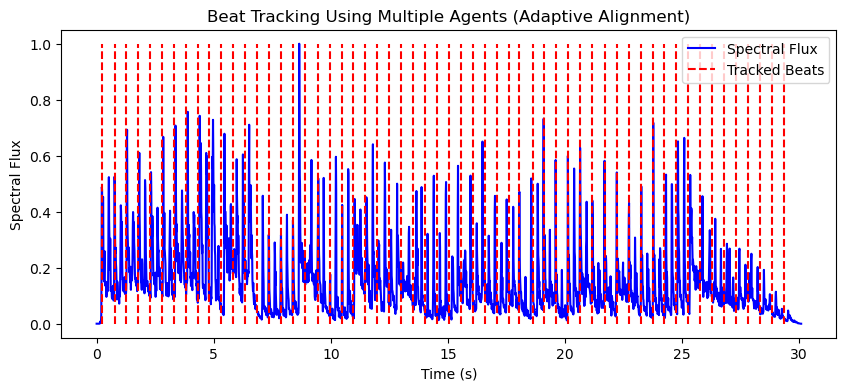

[ 0.22058957  0.7662585   1.24226757  1.75310658  2.26394558  2.77478458
  3.28562358  3.79646259  4.30730159  4.81814059  5.32897959  5.83981859
  6.3506576   6.8614966   7.34911565  7.87156463  8.38240363  8.90485261
  9.46213152  9.97297052 10.48380952 10.94820862 11.45904762 11.96988662
 12.48072562 12.99156463 13.50240363 14.01324263 14.52408163 15.03492063
 15.54575964 16.05659864 16.56743764 17.07827664 17.58911565 18.05351474
 18.61079365 19.08680272 19.59764172 20.1200907  20.64253968 21.16498866
 21.68743764 22.20988662 22.7323356  23.25478458 23.76562358 24.23002268
 24.74086168 25.25170068 25.76253968 26.27337868 26.78421769 27.29505669
 27.80589569 28.31673469 28.8275737  29.3384127 ]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def beat_tracking_adaptive(onset_times, tempo_bpm, tolerance=0.05, max_gap=2.0):

    beat_interval = 60 / tempo_bpm  # Convert BPM to seconds per beat
    agent_scores = []  # Store the score for each agent
    agent_sequences = []  # Store the beat sequences for each agent

    for start_onset in onset_times:
        beat_sequence = [start_onset]  # Initialize beat sequence with the first onset
        current_time = start_onset
        while current_time < onset_times[-1]:  # Continue generating beats until the last onset
            current_time += beat_interval  # Predict the next beat position

            # Find the closest onset
            closest_onset = onset_times[0]  # Start with the first onset as the closest
            min_diff = abs(closest_onset - current_time)  # Compute initial difference

            for onset in onset_times:  # Iterate through all onsets
                diff = abs(onset - current_time)  # Compute difference for each onset
                if diff < min_diff:  # If a smaller difference is found, update
                    closest_onset = onset
                    min_diff = diff

            # If the closest onset is within the tolerance range, align to it
            if abs(closest_onset - current_time) < tolerance:
                beat_sequence.append(closest_onset)
            else:
                beat_sequence.append(current_time)  # Otherwise, keep the predicted beat

        # Scoring metric: Ratio of aligned beats to total onsets (higher score means better alignment)
        score = len(beat_sequence) / len(onset_times)
        agent_scores.append(score)
        agent_sequences.append(beat_sequence)

    # Select the agent with the highest score (best alignment)
    best_index = np.argmax(agent_scores)
    best_beat_sequence = agent_sequences[best_index]
    return np.array(best_beat_sequence)

# Compute beat tracking
beat_sequence = beat_tracking_adaptive(onset_times, tempo_bpm)

# Plot detected beats
plt.figure(figsize=(10, 4))
plt.plot(times, spectral_flux, label="Spectral Flux", color='b')
plt.vlines(beat_sequence, ymin=0, ymax=max(spectral_flux), color='r', linestyle='--', label="Tracked Beats")
plt.title("Beat Tracking Using Multiple Agents (Adaptive Alignment)")
plt.xlabel("Time (s)")
plt.ylabel("Spectral Flux")
plt.legend()
plt.show()

print(beat_sequence)
